In [1]:
import gzip
import heapq
import io
import json
import os
import random
import re
import sys
import time
from collections import Counter, defaultdict

import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = "data"
MODEL_DIR = "models"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("python:", sys.version.split()[0])

python: 3.11.9


In [2]:
CONFIG = {
    "language": "gu",              # Gujarati

    # corpus: 1 000 000 training sentences + 1000 dev + 1000 test
    "n_train": 1000000,
    "n_dev": 1000,
    "n_test": 1000,
    "max_paragraphs": 4000000,     # safety cap on how much of the file we stream

    # sentence filters
    "min_chars": 15,
    "max_chars": 400,
    "min_words": 3,

    # length-stratified dev/test sampling
    "n_length_bins": 10,

    # experiment grid
    "train_sizes": [100000, 300000, 500000, 1000000],
    "vocab_sizes": [20000, 30000, 50000],

    # tokenizer training
    "min_word_freq": 2,            # drop word types seen only once (big speed-up, tiny effect)
    "max_word_chars": 100,         # words longer than this are [UNK] at encode time
}

# handy shorthands used by the reporting cells
MID_VOCAB = sorted(CONFIG["vocab_sizes"])[len(CONFIG["vocab_sizes"]) // 2]
EXTREME_VOCABS = [min(CONFIG["vocab_sizes"]), max(CONFIG["vocab_sizes"])]

CONFIG

{'language': 'gu',
 'n_train': 1000000,
 'n_dev': 1000,
 'n_test': 1000,
 'max_paragraphs': 4000000,
 'min_chars': 15,
 'max_chars': 400,
 'min_words': 3,
 'n_length_bins': 10,
 'train_sizes': [100000, 300000, 500000, 1000000],
 'vocab_sizes': [20000, 30000, 50000],
 'min_word_freq': 2,
 'max_word_chars': 100}

In [3]:
from huggingface_hub import HfApi, hf_hub_url

try:
    from huggingface_hub import get_token
except ImportError:
    from huggingface_hub import HfFolder

    def get_token():
        return HfFolder.get_token()

import requests

REPO_ID = "ai4bharat/IndicCorpV2"


def find_language_file(lang, repo_id=REPO_ID):
    """Locate the monolingual text file for `lang` inside the dataset repository."""
    files = HfApi().list_repo_files(repo_id, repo_type="dataset")
    pattern = re.compile(r"(?:^|/)(" + re.escape(lang) + r"(?:[_-][A-Za-z]{4})?)\.txt(\.gz)?$")
    candidates = [p for p in files if pattern.search(p)]
    if not candidates:
        raise FileNotFoundError(
            "no file for language %r; available: %s" %
            (lang, sorted({p.split("/")[-1] for p in files})[:40]))
    return min(candidates, key=len)


def stream_lines(repo_path, max_lines, repo_id=REPO_ID, timeout=120):
    url = hf_hub_url(repo_id, repo_path, repo_type="dataset")
    token = get_token()
    headers = {"Authorization": "Bearer " + token} if token else {}
    with requests.get(url, headers=headers, stream=True, timeout=timeout) as resp:
        resp.raise_for_status()
        raw = gzip.GzipFile(fileobj=resp.raw) if repo_path.endswith(".gz") else resp.raw
        for i, line in enumerate(io.TextIOWrapper(raw, encoding="utf-8", errors="ignore")):
            if i >= max_lines:
                break
            yield line

d:\SVNIT\Semester - 7\Introduction to Large Language Models\Practicals\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
DANDA = "।"
DOUBLE_DANDA = "॥"
HARD_STOPS = DANDA + DOUBLE_DANDA + "…" + "!?"

_HARD_SPLIT = re.compile(r"(?<=[" + re.escape(HARD_STOPS) + r"])\s+|\n+")
_DOT_SPLIT = re.compile(r"(?<![A-Z]\.)(?<!\d\.)(?<=\.)\s+(?!\d)")
_WS = re.compile(r"\s+")
_URL = re.compile(r"https?://\S+|www\.\S+|\S+@\S+\.\S+")

# Gujarati block is U+0A80-U+0AFF; the pre-tokenizer below keeps a syllable cluster together
GUJARATI = "઀-૿"
_GU_CHAR = re.compile("[" + GUJARATI + "]")


def sentence_tokenize(paragraph):
    paragraph = _URL.sub(" ", paragraph)
    out = []
    for chunk in _HARD_SPLIT.split(paragraph):
        if not chunk:
            continue
        for piece in _DOT_SPLIT.split(chunk):
            piece = _WS.sub(" ", piece).strip()
            if piece:
                out.append(piece)
    return out


def acceptable(sentence, cfg=CONFIG):
    n = len(sentence)
    if n < cfg["min_chars"] or n > cfg["max_chars"]:
        return False
    if sentence.count(" ") + 1 < cfg["min_words"]:
        return False
    # keep sentences that are genuinely Gujarati rather than stray Latin boilerplate
    gu = len(_GU_CHAR.findall(sentence))
    return gu / n >= 0.5


print(sentence_tokenize("આ પહેલું વાક્ય છે" + DANDA + " આ બીજું વાક્ય છે" + DANDA))

['આ પહેલું વાક્ય છે।', 'આ બીજું વાક્ય છે।']


In [5]:
CORPUS_PATH = os.path.join(DATA_DIR, "gu_sentences.txt")
TOTAL_NEEDED = CONFIG["n_train"] + CONFIG["n_dev"] + CONFIG["n_test"]


def build_corpus(path=CORPUS_PATH, cfg=CONFIG):
    """Stream, sentence-tokenize, de-duplicate and cache `TOTAL_NEEDED` Gujarati sentences."""
    if os.path.exists(path):
        with io.open(path, encoding="utf-8") as f:
            sentences = [line.rstrip("\n") for line in f]
        print("loaded %d cached sentences from %s" % (len(sentences), path))
        return sentences

    repo_path = find_language_file(cfg["language"])
    print("streaming", repo_path)
    seen, kept = set(), []
    t0 = time.time()
    try:
        for i, line in enumerate(stream_lines(repo_path, cfg["max_paragraphs"])):
            for s in sentence_tokenize(line):
                if s not in seen and acceptable(s, cfg):
                    seen.add(s)
                    kept.append(s)
                    if len(kept) >= TOTAL_NEEDED:
                        raise StopIteration
            if i % 100000 == 0 and i:
                print("  %8d paragraphs -> %9d sentences  (%.0fs)" %
                      (i, len(kept), time.time() - t0))
    except StopIteration:
        pass
    print("collected %d sentences in %.0fs" % (len(kept), time.time() - t0))
    with io.open(path, "w", encoding="utf-8", newline="\n") as f:
        f.write("\n".join(kept))
    print("cached ->", path)
    return kept


sentences = build_corpus()
print("\ntotal sentences:", len(sentences))
print("example:", sentences[0])

streaming data/gu.txt
    100000 paragraphs ->    132924 sentences  (9s)
    200000 paragraphs ->    266308 sentences  (16s)
    300000 paragraphs ->    399476 sentences  (23s)
    400000 paragraphs ->    529767 sentences  (29s)
    500000 paragraphs ->    660866 sentences  (36s)
    600000 paragraphs ->    791343 sentences  (43s)
    700000 paragraphs ->    921808 sentences  (49s)
collected 1002000 sentences in 53s
cached -> data\gu_sentences.txt

total sentences: 1002000
example: આ વીડિયો જુઓ: ઊંઝા માર્કેટયાર્ડ આજથી 25 જુલાઈ સુધી બંધ


In [6]:
def word_count(sentence):
    return sentence.count(" ") + 1


lengths = np.array([word_count(s) for s in sentences])
print("corpus length in words: min %d  median %d  mean %.1f  p95 %d  max %d" % (
    lengths.min(), int(np.median(lengths)), lengths.mean(),
    int(np.percentile(lengths, 95)), lengths.max()))

corpus length in words: min 3  median 13  mean 15.0  p95 32  max 85


In [7]:
def length_stratified_split(sentences, lengths, cfg=CONFIG, seed=SEED):
    """Hold out `n_dev` + `n_test` sentences spread evenly over the length quantiles."""
    rng = random.Random(seed)
    n_bins = cfg["n_length_bins"]

    # equal-frequency bins over sentence length
    edges = np.quantile(lengths, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1  # make the last bin inclusive
    bin_of = np.clip(np.digitize(lengths, edges[1:-1], right=False), 0, n_bins - 1)

    buckets = defaultdict(list)
    for idx, b in enumerate(bin_of):
        buckets[int(b)].append(idx)
    for b in buckets:
        rng.shuffle(buckets[b])

    per_bin_dev = cfg["n_dev"] // n_bins
    per_bin_test = cfg["n_test"] // n_bins
    dev_idx, test_idx = [], []
    for b in range(n_bins):
        pool = buckets[b]
        need = per_bin_dev + per_bin_test
        if len(pool) < need:
            raise ValueError("length bin %d has only %d sentences" % (b, len(pool)))
        dev_idx += pool[:per_bin_dev]
        test_idx += pool[per_bin_dev:need]

    # top up in case n_dev / n_test are not divisible by the number of bins
    taken = set(dev_idx) | set(test_idx)
    spare = [i for i in range(len(sentences)) if i not in taken]
    rng.shuffle(spare)
    while len(dev_idx) < cfg["n_dev"]:
        dev_idx.append(spare.pop())
    while len(test_idx) < cfg["n_test"]:
        test_idx.append(spare.pop())

    held_out = set(dev_idx) | set(test_idx)
    train_idx = [i for i in range(len(sentences)) if i not in held_out]
    rng.shuffle(train_idx)
    rng.shuffle(dev_idx)
    rng.shuffle(test_idx)

    take = lambda ix: [sentences[i] for i in ix]
    return take(train_idx), take(dev_idx), take(test_idx), edges


train_sents, dev_sents, test_sents, bin_edges = length_stratified_split(sentences, lengths)
train_sents = train_sents[:CONFIG["n_train"]]

print("train %d   dev %d   test %d" % (len(train_sents), len(dev_sents), len(test_sents)))
print("length bin edges (words):", [int(e) for e in bin_edges])

train 1000000   dev 1000   test 1000
length bin edges (words): [3, 6, 8, 10, 11, 13, 15, 17, 21, 26, 86]


In [8]:
def length_summary(name, sents):
    L = np.array([word_count(s) for s in sents])
    print("%-6s n=%-8d min %-4d p25 %-4d median %-4d p75 %-4d max %-4d  mean %.1f  sd %.1f" % (
        name, len(L), L.min(), int(np.percentile(L, 25)), int(np.median(L)),
        int(np.percentile(L, 75)), L.max(), L.mean(), L.std()))


length_summary("train", train_sents[:200000])   # a sample, for speed
length_summary("dev", dev_sents)
length_summary("test", test_sents)

# the point of the stratification: dev/test cover the whole range, not one narrow band
dev_L = np.array([word_count(s) for s in dev_sents])
print("\ndev sentences per length bin:",
      [int(((dev_L >= bin_edges[b]) & (dev_L < bin_edges[b + 1])).sum())
       for b in range(CONFIG["n_length_bins"])])

train  n=200000   min 3    p25 9    median 13   p75 19   max 80    mean 15.0  sd 9.0
dev    n=1000     min 3    p25 8    median 12   p75 18   max 61    mean 14.5  sd 8.7
test   n=1000     min 3    p25 9    median 12   p75 18   max 60    mean 14.5  sd 8.8

dev sentences per length bin: [100, 100, 100, 100, 100, 100, 100, 100, 100, 100]


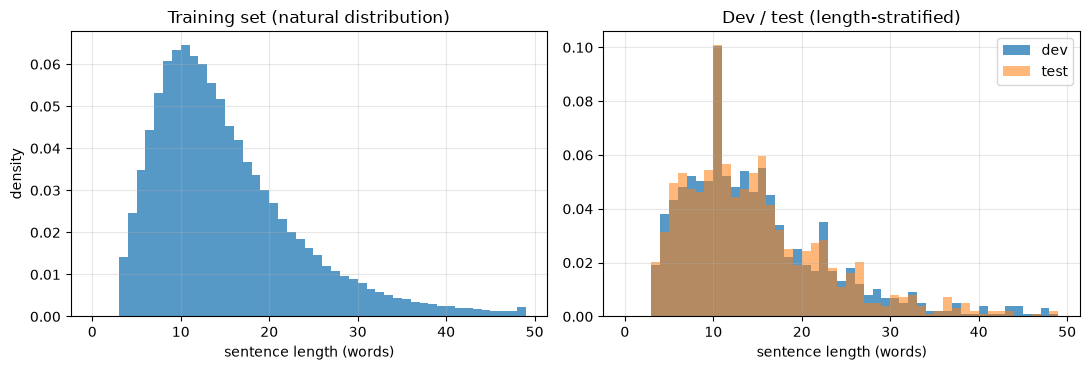

In [9]:
import matplotlib.pyplot as plt

train_L = np.array([word_count(s) for s in train_sents[:200000]])
test_L = np.array([word_count(s) for s in test_sents])
hi = int(np.percentile(train_L, 99))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(train_L, bins=np.arange(0, hi + 2), density=True, alpha=.75)
ax[0].set_title("Training set (natural distribution)")
ax[0].set_xlabel("sentence length (words)"); ax[0].set_ylabel("density")
ax[1].hist(dev_L, bins=np.arange(0, hi + 2), density=True, alpha=.75, label="dev")
ax[1].hist(test_L, bins=np.arange(0, hi + 2), density=True, alpha=.55, label="test")
ax[1].set_title("Dev / test (length-stratified)")
ax[1].set_xlabel("sentence length (words)"); ax[1].legend()
for a in ax:
    a.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [10]:
for name, sents in (("train", train_sents), ("dev", dev_sents), ("test", test_sents)):
    path = os.path.join(DATA_DIR, "gu_%s.txt" % name)
    with io.open(path, "w", encoding="utf-8", newline="\n") as f:
        f.write("\n".join(sents))
    print("saved %-24s %d sentences" % (path, len(sents)))

saved data\gu_train.txt        1000000 sentences
saved data\gu_dev.txt          1000 sentences
saved data\gu_test.txt         1000 sentences


In [11]:
_PRETOK = re.compile(
    "[" + GUJARATI + "]+"      # Gujarati orthographic word
    "|[A-Za-z]+"               # Latin word
    "|[0-9]+"                  # digits
    "|[^\\s]"                  # any other single non-space character
)


def pre_tokenize(text):
    return _PRETOK.findall(text)


demo = "ગુજરાત ભારતનું એક રાજ્ય છે" + DANDA + " ISO 3166 code: GJ."
print(pre_tokenize(demo))

['ગુજરાત', 'ભારતનું', 'એક', 'રાજ્ય', 'છે', '।', 'ISO', '3166', 'code', ':', 'GJ', '.']


In [12]:
def word_frequencies(sentences, min_freq=1):
    """Word-type -> count table over a list of sentences."""
    freqs = Counter()
    for s in sentences:
        freqs.update(_PRETOK.findall(s))
    if min_freq > 1:
        freqs = Counter({w: c for w, c in freqs.items() if c >= min_freq})
    return freqs


# The training sizes are nested prefixes of the same list, so the frequency tables can be built
# cumulatively instead of re-scanning the corpus four times.
def cumulative_word_frequencies(sentences, sizes, min_freq=1):
    out, running, prev = {}, Counter(), 0
    for size in sorted(sizes):
        for s in sentences[prev:size]:
            running.update(_PRETOK.findall(s))
        prev = size
        if min_freq > 1:
            out[size] = Counter({w: c for w, c in running.items() if c >= min_freq})
        else:
            out[size] = Counter(running)
        print("  %9d sentences -> %9d word types (%d kept after min_freq=%d)" % (
            size, len(running), len(out[size]), min_freq))
    return out


t0 = time.time()
WORD_FREQS = cumulative_word_frequencies(train_sents, CONFIG["train_sizes"],
                                         CONFIG["min_word_freq"])
print("pre-tokenization done in %.0fs" % (time.time() - t0))

     100000 sentences ->    140811 word types (58037 kept after min_freq=2)
     300000 sentences ->    269438 word types (114669 kept after min_freq=2)
     500000 sentences ->    361964 word types (156006 kept after min_freq=2)
    1000000 sentences ->    538928 word types (235322 kept after min_freq=2)
pre-tokenization done in 6s


In [13]:
UNK = "[UNK]"
EOW = "</w>"


class BPETokenizer:
    """A trained BPE model: an ordered merge list plus the vocabulary it induces."""

    def __init__(self, merges, alphabet, max_word_chars=CONFIG["max_word_chars"]):
        self.merges = list(merges)                       # [((a, b), new_symbol), ...]
        self.ranks = {pair: i for i, (pair, _) in enumerate(self.merges)}
        self.alphabet = set(alphabet)
        self.vocab = [UNK] + sorted(self.alphabet) + [new for _, new in self.merges]
        self.token2id = {t: i for i, t in enumerate(self.vocab)}
        self.max_word_chars = max_word_chars
        self._cache = {}

    @property
    def vocab_size(self):
        return len(self.vocab)

    def _encode_word(self, word):
        cached = self._cache.get(word)
        if cached is not None:
            return cached
        if len(word) > self.max_word_chars:
            self._cache[word] = [UNK]
            return [UNK]

        symbols = list(word[:-1]) + [word[-1] + EOW]
        symbols = [s if s in self.alphabet else UNK for s in symbols]

        while len(symbols) > 1:
            # merge the pair with the lowest rank (i.e. learned earliest)
            best_rank, best_i = None, None
            for i in range(len(symbols) - 1):
                r = self.ranks.get((symbols[i], symbols[i + 1]))
                if r is not None and (best_rank is None or r < best_rank):
                    best_rank, best_i = r, i
            if best_i is None:
                break
            symbols[best_i:best_i + 2] = [symbols[best_i] + symbols[best_i + 1]]

        self._cache[word] = symbols
        return symbols

    def tokenize(self, text):
        out = []
        for word in _PRETOK.findall(text):
            out.extend(self._encode_word(word))
        return out

    def encode(self, text):
        unk = self.token2id[UNK]
        return [self.token2id.get(t, unk) for t in self.tokenize(text)]

    def decode(self, tokens):
        return "".join(tokens).replace(EOW, " ").strip()

    # ---------------------------------------------------------------- persistence
    def save(self, path):
        with io.open(path, "w", encoding="utf-8") as f:
            json.dump({"merges": [[list(p), n] for p, n in self.merges],
                       "alphabet": sorted(self.alphabet)}, f, ensure_ascii=False)

    @classmethod
    def load(cls, path):
        with io.open(path, encoding="utf-8") as f:
            blob = json.load(f)
        return cls([((a, b), n) for (a, b), n in blob["merges"]], blob["alphabet"])

In [14]:
def train_bpe(word_freqs, snapshot_sizes, verbose=True):
    """Train BPE and return {target_vocab_size: BPETokenizer}.

    Trains once up to max(snapshot_sizes) and truncates the merge list for the smaller targets,
    which is exact because BPE appends merges greedily one at a time.
    """
    snapshot_sizes = sorted(snapshot_sizes)
    t_start = time.time()

    # ---- initial state ------------------------------------------------------------
    words, freqs = [], []
    for w, f in word_freqs.items():
        words.append(list(w[:-1]) + [w[-1] + EOW])
        freqs.append(f)

    alphabet = set()
    for syms in words:
        alphabet.update(syms)
    base = len(alphabet) + 1          # + [UNK]
    max_merges = max(snapshot_sizes) - base
    if max_merges <= 0:
        raise ValueError("target vocabulary %d is smaller than the alphabet (%d)" %
                         (max(snapshot_sizes), base))
    if verbose:
        print("  alphabet %d symbols | %d word types | up to %d merges" %
              (len(alphabet), len(words), max_merges))

    pair_freq = Counter()
    pair_where = defaultdict(set)
    for i, syms in enumerate(words):
        f = freqs[i]
        for j in range(len(syms) - 1):
            p = (syms[j], syms[j + 1])
            pair_freq[p] += f
            pair_where[p].add(i)

    heap = [(-f, p) for p, f in pair_freq.items()]
    heapq.heapify(heap)

    merges = []
    snapshots = {}
    next_snapshot = 0

    while len(merges) < max_merges:
        # ---- pick the most frequent live pair (lazy heap) --------------------------
        best = None
        while heap:
            neg, pair = heapq.heappop(heap)
            if pair_freq.get(pair, 0) == -neg and -neg > 0:
                best = pair
                break
        if best is None:
            if verbose:
                print("  no pairs left after %d merges" % len(merges))
            break

        a, b = best
        new_symbol = a + b
        merges.append((best, new_symbol))
        affected = pair_where.pop(best, set())
        pair_freq.pop(best, None)

        # ---- apply the merge, rebuilding each affected word's pair contributions ----
        touched_pairs = set()
        for i in affected:
            syms = words[i]
            f = freqs[i]
            merged, j, changed = [], 0, False
            while j < len(syms):
                if j < len(syms) - 1 and syms[j] == a and syms[j + 1] == b:
                    merged.append(new_symbol)
                    j += 2
                    changed = True
                else:
                    merged.append(syms[j])
                    j += 1
            if not changed:
                continue

            # withdraw every pair the old form contributed ...
            for j in range(len(syms) - 1):
                pair = (syms[j], syms[j + 1])
                if pair == best:
                    continue                      # already removed above
                pair_freq[pair] -= f
                touched_pairs.add(pair)
                if pair_freq[pair] <= 0:
                    pair_freq.pop(pair, None)
                    pair_where.pop(pair, None)
                else:
                    where = pair_where.get(pair)
                    if where is not None:
                        where.discard(i)
            # ... and register every pair the new form contributes
            for j in range(len(merged) - 1):
                pair = (merged[j], merged[j + 1])
                pair_freq[pair] += f
                pair_where[pair].add(i)
                touched_pairs.add(pair)
            words[i] = merged

        for p in touched_pairs:
            f = pair_freq.get(p, 0)
            if f > 0:
                heapq.heappush(heap, (-f, p))

        # ---- snapshot ---------------------------------------------------------------
        while (next_snapshot < len(snapshot_sizes)
               and base + len(merges) >= snapshot_sizes[next_snapshot]):
            target = snapshot_sizes[next_snapshot]
            snapshots[target] = BPETokenizer(merges[:target - base], alphabet)
            if verbose:
                print("    snapshot vocab %6d after %6d merges  (%.0fs)" %
                      (snapshots[target].vocab_size, target - base, time.time() - t_start))
            next_snapshot += 1

        if verbose and len(merges) % 10000 == 0:
            print("    %6d merges  (%.0fs)" % (len(merges), time.time() - t_start))

    # any target we could not reach (alphabet too small / pairs exhausted)
    for target in snapshot_sizes:
        if target not in snapshots:
            snapshots[target] = BPETokenizer(merges, alphabet)
    if verbose:
        print("  BPE trained in %.0fs" % (time.time() - t_start))
    return snapshots

In [15]:
# quick correctness check on the textbook example
_toy = Counter({"low": 5, "lower": 2, "newest": 6, "widest": 3})
_snap = train_bpe(_toy, [len(set("".join(_toy)) | {c + EOW for c in "wrt"}) + 12], verbose=False)
_tok = list(_snap.values())[0]
print("first merges:", [(a + "+" + b, n) for (a, b), n in _tok.merges[:6]])
print("tokenize 'newest' ->", _tok._encode_word("newest"))
print("tokenize 'lowest' ->", _tok._encode_word("lowest"))
print("round trip:", _tok.decode(_tok.tokenize("low lower newest")))
assert _tok.decode(_tok.tokenize("low lower newest")) == "low lower newest"
print("BPE round-trip OK")

first merges: [('e+s', 'es'), ('es+t</w>', 'est</w>'), ('l+o', 'lo'), ('e+w', 'ew'), ('ew+est</w>', 'ewest</w>'), ('n+ewest</w>', 'newest</w>')]
tokenize 'newest' -> ['newest</w>']
tokenize 'lowest' -> ['low', 'est</w>']
round trip: low lower newest
BPE round-trip OK


In [16]:
CONT = "##"


class WordPieceTokenizer:
    def __init__(self, vocab, max_word_chars=CONFIG["max_word_chars"]):
        self.vocab = list(vocab)
        self.vocab_set = set(self.vocab)
        self.token2id = {t: i for i, t in enumerate(self.vocab)}
        self.max_word_chars = max_word_chars
        self._cache = {}

    @property
    def vocab_size(self):
        return len(self.vocab)

    def _encode_word(self, word):
        """Greedy longest-match-first, the standard WordPiece inference rule."""
        cached = self._cache.get(word)
        if cached is not None:
            return cached
        if len(word) > self.max_word_chars:
            self._cache[word] = [UNK]
            return [UNK]

        pieces, start = [], 0
        while start < len(word):
            end = len(word)
            found = None
            while end > start:
                piece = word[start:end]
                if start > 0:
                    piece = CONT + piece
                if piece in self.vocab_set:
                    found = piece
                    break
                end -= 1
            if found is None:          # no prefix of the remainder is in the vocabulary
                pieces = [UNK]
                break
            pieces.append(found)
            start = end
        self._cache[word] = pieces
        return pieces

    def tokenize(self, text):
        out = []
        for word in _PRETOK.findall(text):
            out.extend(self._encode_word(word))
        return out

    def encode(self, text):
        unk = self.token2id[UNK]
        return [self.token2id.get(t, unk) for t in self.tokenize(text)]

    def decode(self, tokens):
        out = []
        for t in tokens:
            if t.startswith(CONT):
                out.append(t[len(CONT):])
            else:
                out.append(" " + t)
        return "".join(out).strip()

    def save(self, path):
        with io.open(path, "w", encoding="utf-8") as f:
            json.dump({"vocab": self.vocab}, f, ensure_ascii=False)

    @classmethod
    def load(cls, path):
        with io.open(path, encoding="utf-8") as f:
            return cls(json.load(f)["vocab"])

In [17]:
def train_wordpiece(word_freqs, snapshot_sizes, verbose=True):
    """Train WordPiece and return {target_vocab_size: WordPieceTokenizer}."""
    snapshot_sizes = sorted(snapshot_sizes)
    t_start = time.time()

    words, freqs = [], []
    for w, f in word_freqs.items():
        words.append([w[0]] + [CONT + c for c in w[1:]])
        freqs.append(f)

    alphabet = set()
    sym_freq = Counter()
    for syms, f in zip(words, freqs):
        alphabet.update(syms)
        for s in syms:
            sym_freq[s] += f

    base = len(alphabet) + 1          # + [UNK]
    max_merges = max(snapshot_sizes) - base
    if max_merges <= 0:
        raise ValueError("target vocabulary %d is smaller than the alphabet (%d)" %
                         (max(snapshot_sizes), base))
    if verbose:
        print("  alphabet %d symbols | %d word types | up to %d merges" %
              (len(alphabet), len(words), max_merges))

    pair_freq = Counter()
    pair_where = defaultdict(set)
    sym_pairs = defaultdict(set)      # symbol -> the pairs it takes part in
    for i, syms in enumerate(words):
        f = freqs[i]
        for j in range(len(syms) - 1):
            pair = (syms[j], syms[j + 1])
            pair_freq[pair] += f
            pair_where[pair].add(i)
            sym_pairs[pair[0]].add(pair)
            sym_pairs[pair[1]].add(pair)

    def score(pair):
        """freq(ab) / (freq(a) * freq(b)) - the WordPiece likelihood criterion."""
        f = pair_freq.get(pair, 0)
        if f <= 0:
            return 0.0
        denom = sym_freq[pair[0]] * sym_freq[pair[1]]
        return f / float(denom) if denom > 0 else 0.0

    def drop_pair(pair):
        pair_freq.pop(pair, None)
        pair_where.pop(pair, None)
        sym_pairs[pair[0]].discard(pair)
        sym_pairs[pair[1]].discard(pair)

    heap = [(-score(p), p) for p in pair_freq]
    heapq.heapify(heap)

    ordered_merges = []               # new tokens, in the order WordPiece learned them
    snapshots = {}
    next_snapshot = 0

    while len(ordered_merges) < max_merges:
        # ---- pick the best-scoring live pair --------------------------------------
        best = None
        while heap:
            neg, pair = heapq.heappop(heap)
            if pair not in pair_freq:
                continue
            live = score(pair)
            if live <= 0:
                continue
            if abs(live + neg) <= 1e-15 * max(1.0, live):
                best = pair
                break
            heapq.heappush(heap, (-live, pair))   # stale entry: re-score and try again
        if best is None:
            if verbose:
                print("  no pairs left after %d merges" % len(ordered_merges))
            break

        a, b = best
        new_symbol = a + b[len(CONT):]            # b is always a continuation piece
        ordered_merges.append(new_symbol)
        affected = pair_where.get(best, set()).copy()
        drop_pair(best)

        # ---- apply the merge, rebuilding each affected word ------------------------
        touched = set()
        for i in affected:
            syms = words[i]
            f = freqs[i]
            merged, j, changed = [], 0, False
            while j < len(syms):
                if j < len(syms) - 1 and syms[j] == a and syms[j + 1] == b:
                    merged.append(new_symbol)
                    j += 2
                    changed = True
                else:
                    merged.append(syms[j])
                    j += 1
            if not changed:
                continue

            for j in range(len(syms) - 1):
                pair = (syms[j], syms[j + 1])
                if pair == best:
                    continue
                pair_freq[pair] -= f
                touched.add(pair)
                if pair_freq[pair] <= 0:
                    drop_pair(pair)
                else:
                    where = pair_where.get(pair)
                    if where is not None:
                        where.discard(i)
            for j in range(len(merged) - 1):
                pair = (merged[j], merged[j + 1])
                pair_freq[pair] += f
                pair_where[pair].add(i)
                sym_pairs[pair[0]].add(pair)
                sym_pairs[pair[1]].add(pair)
                touched.add(pair)

            # symbol counts feed the score, so keep them exact
            for s in syms:
                sym_freq[s] -= f
            for s in merged:
                sym_freq[s] += f
            words[i] = merged

        # freq(a) and freq(b) just fell, which RAISES the score of every other pair
        # containing a or b - those entries must be re-pushed or the heap would hand back
        # a worse pair from a stale, too-low key.
        for sym in (a, b):
            touched.update(sym_pairs.get(sym, ()))
        for pair in touched:
            s = score(pair)
            if s > 0:
                heapq.heappush(heap, (-s, pair))

        # ---- snapshot ---------------------------------------------------------------
        while (next_snapshot < len(snapshot_sizes)
               and base + len(ordered_merges) >= snapshot_sizes[next_snapshot]):
            target = snapshot_sizes[next_snapshot]
            vocab = [UNK] + sorted(alphabet) + ordered_merges[:target - base]
            snapshots[target] = WordPieceTokenizer(vocab)
            if verbose:
                print("    snapshot vocab %6d after %6d merges  (%.0fs)" %
                      (snapshots[target].vocab_size, target - base, time.time() - t_start))
            next_snapshot += 1

        if verbose and len(ordered_merges) % 10000 == 0:
            print("    %6d merges  (%.0fs)" % (len(ordered_merges), time.time() - t_start))

    for target in snapshot_sizes:
        if target not in snapshots:
            snapshots[target] = WordPieceTokenizer([UNK] + sorted(alphabet) + ordered_merges)
    if verbose:
        print("  WordPiece trained in %.0fs" % (time.time() - t_start))
    return snapshots

In [18]:
_toy = Counter({"low": 5, "lower": 2, "newest": 6, "widest": 3})
_alpha = set("low") | set("lower") | set("newest") | set("widest")
_snap = train_wordpiece(_toy, [2 * len(_alpha) + 12], verbose=False)
_wp = list(_snap.values())[0]
print("vocab sample:", _wp.vocab[:12], "...")
print("tokenize 'newest' ->", _wp._encode_word("newest"))
print("tokenize 'lowest' ->", _wp._encode_word("lowest"))
print("round trip:", _wp.decode(_wp.tokenize("low lower newest")))
assert _wp.decode(_wp.tokenize("low lower newest")) == "low lower newest"
print("WordPiece round-trip OK")

vocab sample: ['[UNK]', '##d', '##e', '##i', '##o', '##r', '##s', '##t', '##w', 'l', 'n', 'w'] ...
tokenize 'newest' -> ['newest']
tokenize 'lowest' -> ['low', '##est']
round trip: low lower newest
WordPiece round-trip OK


In [19]:
def model_path(algo, n_sents, vocab):
    return os.path.join(MODEL_DIR, "%s_%d_%d.json" % (algo, n_sents, vocab))


def get_tokenizers(algo, n_sents, vocab_sizes, word_freqs):
    """Load the (n_sents x vocab) tokenizers from cache, training only what is missing."""
    loader = BPETokenizer.load if algo == "bpe" else WordPieceTokenizer.load
    out, missing = {}, []
    for v in vocab_sizes:
        p = model_path(algo, n_sents, v)
        if os.path.exists(p):
            out[v] = loader(p)
        else:
            missing.append(v)
    if missing:
        print("training %s on %d sentences (targets %s)" % (algo.upper(), n_sents, missing))
        trainer = train_bpe if algo == "bpe" else train_wordpiece
        # train once to the largest missing target; smaller ones are prefixes of it
        snaps = trainer(word_freqs, vocab_sizes)
        for v in vocab_sizes:
            snaps[v].save(model_path(algo, n_sents, v))
            out[v] = snaps[v]
    else:
        print("loaded cached %s models for %d sentences" % (algo.upper(), n_sents))
    return out


TOKENIZERS = {}
for algo in ("bpe", "wordpiece"):
    for n_sents in CONFIG["train_sizes"]:
        for v, tok in get_tokenizers(algo, n_sents, CONFIG["vocab_sizes"],
                                     WORD_FREQS[n_sents]).items():
            TOKENIZERS[(algo, n_sents, v)] = tok

print("\n%d tokenizers ready" % len(TOKENIZERS))

training BPE on 100000 sentences (targets [20000, 30000, 50000])
  alphabet 358 symbols | 58037 word types | up to 49641 merges
     10000 merges  (3s)
    snapshot vocab  20000 after  19641 merges  (3s)
     20000 merges  (3s)
    snapshot vocab  30000 after  29641 merges  (3s)
     30000 merges  (3s)
     40000 merges  (4s)
    snapshot vocab  50000 after  49641 merges  (4s)
  BPE trained in 4s
training BPE on 300000 sentences (targets [20000, 30000, 50000])
  alphabet 444 symbols | 114669 word types | up to 49555 merges
     10000 merges  (8s)
    snapshot vocab  20000 after  19555 merges  (8s)
     20000 merges  (8s)
    snapshot vocab  30000 after  29555 merges  (9s)
     30000 merges  (9s)
     40000 merges  (9s)
    snapshot vocab  50000 after  49555 merges  (9s)
  BPE trained in 9s
training BPE on 500000 sentences (targets [20000, 30000, 50000])
  alphabet 500 symbols | 156006 word types | up to 49499 merges
     10000 merges  (10s)
    snapshot vocab  20000 after  19499 merges

In [20]:
def evaluate(tokenizer, sentences, is_wordpiece):
    n_tokens = n_words = n_chars = n_unk = n_cont = 0
    tok_len_sum = 0
    used = set()
    per_sentence = []
    for s in sentences:
        toks = tokenizer.tokenize(s)
        per_sentence.append(len(toks))
        n_tokens += len(toks)
        n_words += len(_PRETOK.findall(s))
        n_chars += len(s.replace(" ", ""))
        for t in toks:
            used.add(t)
            if t == UNK:
                n_unk += 1
                continue
            if is_wordpiece:
                if t.startswith(CONT):
                    n_cont += 1
                    tok_len_sum += len(t) - len(CONT)
                else:
                    tok_len_sum += len(t)
            else:
                if t.endswith(EOW):
                    tok_len_sum += len(t) - len(EOW)
                else:
                    n_cont += 1
                    tok_len_sum += len(t)
    return {
        "tokens_per_sentence": n_tokens / len(sentences),
        "fertility": n_tokens / n_words,
        "chars_per_token": n_chars / n_tokens,
        "avg_token_chars": tok_len_sum / max(1, n_tokens - n_unk),
        "continuation_pct": 100.0 * n_cont / n_tokens,
        "unk_pct": 100.0 * n_unk / n_tokens,
        "vocab_used_pct": 100.0 * len(used) / tokenizer.vocab_size,
        "n_tokens": n_tokens,
        "sentence_token_counts": per_sentence,
    }


rows = []
for (algo, n_sents, vocab), tok in sorted(TOKENIZERS.items()):
    for split_name, split in (("dev", dev_sents), ("test", test_sents)):
        m = evaluate(tok, split, is_wordpiece=(algo == "wordpiece"))
        m.update({"algo": algo, "train_size": n_sents, "vocab_size": vocab,
                  "split": split_name, "actual_vocab": tok.vocab_size})
        rows.append(m)
print("evaluated %d (tokenizer, split) combinations" % len(rows))

evaluated 48 (tokenizer, split) combinations


In [21]:
def show(rows, split="test"):
    head = "%-10s %10s %8s %8s %10s %11s %8s %8s" % (
        "algo", "train", "vocab", "tok/sent", "fertility", "chars/token", "cont%", "unk%")
    print(head)
    print("-" * len(head))
    for r in rows:
        if r["split"] != split:
            continue
        print("%-10s %10d %8d %8.2f %10.3f %11.3f %8.2f %8.3f" % (
            r["algo"], r["train_size"], r["vocab_size"], r["tokens_per_sentence"],
            r["fertility"], r["chars_per_token"], r["continuation_pct"], r["unk_pct"]))


print("TEST SET")
show(rows, "test")
print("\nDEV SET")
show(rows, "dev")

TEST SET
algo            train    vocab tok/sent  fertility chars/token    cont%     unk%
--------------------------------------------------------------------------------
bpe            100000    20000    20.48      1.243       3.538    19.57    0.005
bpe            100000    30000    19.56      1.187       3.704    15.79    0.005
bpe            100000    50000    18.74      1.138       3.866    12.12    0.005
bpe            300000    20000    20.39      1.238       3.554    19.21    0.005
bpe            300000    30000    19.44      1.180       3.727    15.28    0.005
bpe            300000    50000    18.54      1.125       3.909    11.14    0.005
bpe            500000    20000    20.38      1.237       3.555    19.17    0.005
bpe            500000    30000    19.42      1.179       3.730    15.20    0.005
bpe            500000    50000    18.49      1.122       3.919    10.91    0.005
bpe           1000000    20000    20.37      1.237       3.556    19.15    0.005
bpe           10000

In [22]:
with io.open(os.path.join(DATA_DIR, "tokenization_metrics.json"), "w", encoding="utf-8") as f:
    json.dump([{k: v for k, v in r.items() if k != "sentence_token_counts"} for r in rows],
              f, ensure_ascii=False, indent=1)

# save the tokenized dev/test data for the best-resourced setting
for algo in ("bpe", "wordpiece"):
    tok = TOKENIZERS[(algo, max(CONFIG["train_sizes"]), MID_VOCAB)]
    for name, split in (("dev", dev_sents), ("test", test_sents)):
        path = os.path.join(DATA_DIR, "%s_%s_tokenized.txt" % (algo, name))
        with io.open(path, "w", encoding="utf-8", newline="\n") as f:
            for s in split:
                f.write(" ".join(tok.tokenize(s)) + "\n")
        print("saved", path)

saved data\bpe_dev_tokenized.txt
saved data\bpe_test_tokenized.txt
saved data\wordpiece_dev_tokenized.txt
saved data\wordpiece_test_tokenized.txt


In [23]:
def pick(rows, algo, split, vocab):
    """All rows for one (algorithm, split, vocabulary), ordered by training size."""
    sel = [r for r in rows if r["algo"] == algo and r["split"] == split
           and r["vocab_size"] == vocab]
    return sorted(sel, key=lambda r: r["train_size"])


def pick_v(rows, algo, split, train_size):
    """All rows for one (algorithm, split, training size), ordered by vocabulary size."""
    sel = [r for r in rows if r["algo"] == algo and r["split"] == split
           and r["train_size"] == train_size]
    return sorted(sel, key=lambda r: r["vocab_size"])

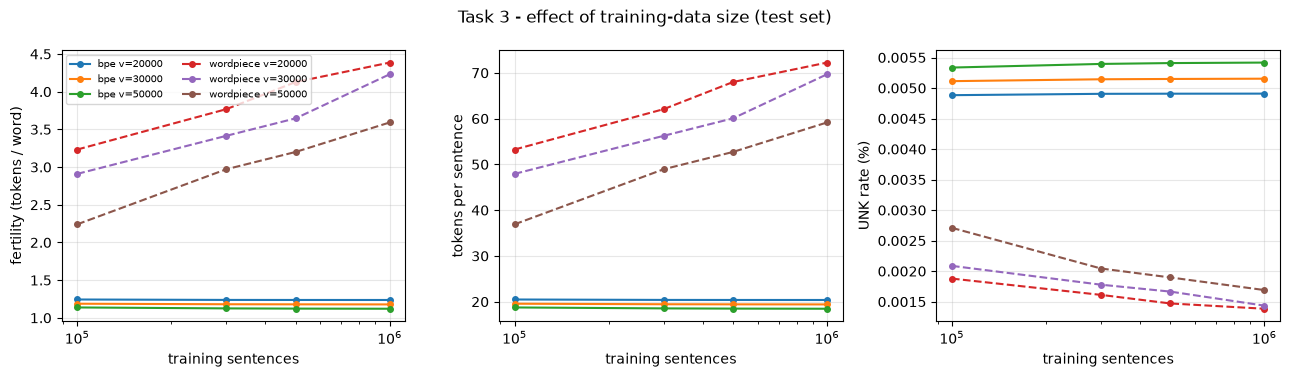

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, metric, label in zip(
        axes,
        ("fertility", "tokens_per_sentence", "unk_pct"),
        ("fertility (tokens / word)", "tokens per sentence", "UNK rate (%)")):
    for algo in ("bpe", "wordpiece"):
        for vocab in CONFIG["vocab_sizes"]:
            sel = pick(rows, algo, "test", vocab)
            ax.plot([r["train_size"] for r in sel], [r[metric] for r in sel],
                    marker="o", ms=4,
                    ls="-" if algo == "bpe" else "--",
                    label="%s v=%d" % (algo, vocab))
    ax.set_xscale("log")
    ax.set_xlabel("training sentences")
    ax.set_ylabel(label)
    ax.grid(alpha=.3)
axes[0].legend(fontsize=7, ncol=2)
fig.suptitle("Task 3 - effect of training-data size (test set)")
plt.tight_layout(); plt.show()

In [25]:
print("effect of training size at vocab = %d (test set)\n" % MID_VOCAB)
head = "%-10s %10s %10s %11s %8s %8s" % ("algo", "train", "fertility", "chars/token",
                                         "cont%", "unk%")
print(head); print("-" * len(head))
for algo in ("bpe", "wordpiece"):
    for r in pick(rows, algo, "test", MID_VOCAB):
        print("%-10s %10d %10.3f %11.3f %8.2f %8.3f" % (
            algo, r["train_size"], r["fertility"], r["chars_per_token"],
            r["continuation_pct"], r["unk_pct"]))
    print()

effect of training size at vocab = 30000 (test set)

algo            train  fertility chars/token    cont%     unk%
--------------------------------------------------------------
bpe            100000      1.187       3.704    15.79    0.005
bpe            300000      1.180       3.727    15.28    0.005
bpe            500000      1.179       3.730    15.20    0.005
bpe           1000000      1.178       3.733    15.12    0.005

wordpiece      100000      2.910       1.512    65.63    0.002
wordpiece      300000      3.414       1.288    70.71    0.002
wordpiece      500000      3.646       1.206    72.57    0.002
wordpiece     1000000      4.231       1.040    76.37    0.001



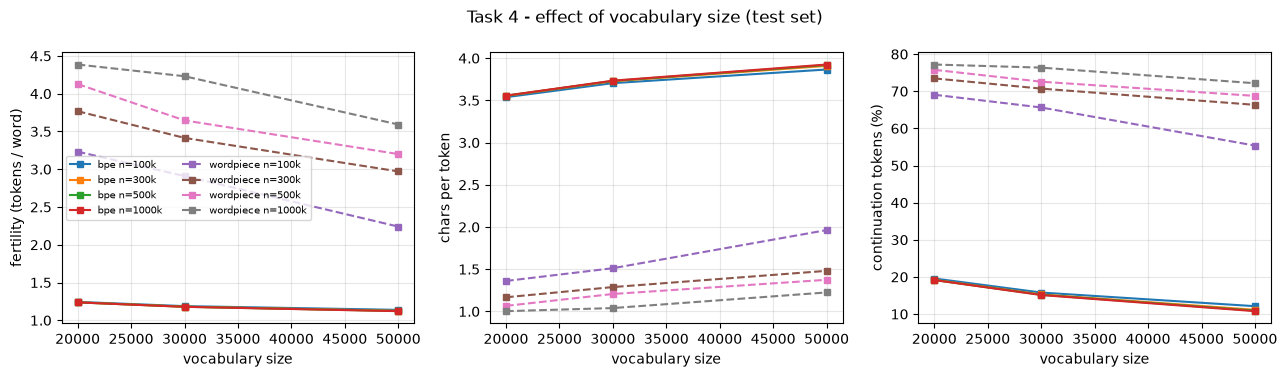

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, metric, label in zip(
        axes,
        ("fertility", "chars_per_token", "continuation_pct"),
        ("fertility (tokens / word)", "chars per token", "continuation tokens (%)")):
    for algo in ("bpe", "wordpiece"):
        for n_sents in CONFIG["train_sizes"]:
            sel = pick_v(rows, algo, "test", n_sents)
            ax.plot([r["vocab_size"] for r in sel], [r[metric] for r in sel],
                    marker="s", ms=4,
                    ls="-" if algo == "bpe" else "--",
                    label="%s n=%dk" % (algo, n_sents // 1000))
    ax.set_xlabel("vocabulary size")
    ax.set_ylabel(label)
    ax.grid(alpha=.3)
axes[0].legend(fontsize=7, ncol=2)
fig.suptitle("Task 4 - effect of vocabulary size (test set)")
plt.tight_layout(); plt.show()

In [27]:
print("effect of vocabulary at %d training sentences (test set)\n" % (
    max(CONFIG["train_sizes"]),))
head = "%-10s %10s %10s %11s %8s %12s" % ("algo", "vocab", "fertility", "chars/token",
                                          "cont%", "vocab used%")
print(head); print("-" * len(head))
for algo in ("bpe", "wordpiece"):
    for r in pick_v(rows, algo, "test", max(CONFIG["train_sizes"])):
        print("%-10s %10d %10.3f %11.3f %8.2f %12.1f" % (
            algo, r["vocab_size"], r["fertility"], r["chars_per_token"],
            r["continuation_pct"], r["vocab_used_pct"]))
    print()

effect of vocabulary at 1000000 training sentences (test set)

algo            vocab  fertility chars/token    cont%  vocab used%
------------------------------------------------------------------
bpe             20000      1.237       3.556    19.15         34.0
bpe             30000      1.178       3.733    15.12         23.7
bpe             50000      1.121       3.925    10.77         14.5

wordpiece       20000      4.386       1.003    77.20          1.4
wordpiece       30000      4.231       1.040    76.37          2.0
wordpiece       50000      3.592       1.225    72.16          2.6



In [28]:
def show_tokenization(sentence, algo, train_sizes=None, vocab_sizes=None):
    train_sizes = train_sizes or CONFIG["train_sizes"]
    vocab_sizes = vocab_sizes or CONFIG["vocab_sizes"]
    print(sentence)
    print("-" * 100)
    for n_sents in train_sizes:
        for v in vocab_sizes:
            toks = TOKENIZERS[(algo, n_sents, v)].tokenize(sentence)
            print("n=%-8d v=%-6d (%2d tokens)  %s" % (n_sents, v, len(toks), " ".join(toks)))
    print()


sample = max(dev_sents, key=lambda s: (20 <= len(s) <= 70, len(s)))
print("=" * 100)
print("BPE")
print("=" * 100)
show_tokenization(sample, "bpe", vocab_sizes=EXTREME_VOCABS)

print("=" * 100)
print("WordPiece")
print("=" * 100)
show_tokenization(sample, "wordpiece", vocab_sizes=EXTREME_VOCABS)

BPE
નાયબ મામલતદારે આવેદનપત્ર સ્વીકારી કલેક્ટરને પહોંચાડવાની ખાતરી આપી હતી.
----------------------------------------------------------------------------------------------------
n=100000   v=20000  (12 tokens)  નાયબ</w> મામલત દારે</w> આવેદનપત્ર</w> સ્વીકારી</w> કલેક્ટરને</w> પહોંચા ડવાની</w> ખાતરી</w> આપી</w> હતી</w> .</w>
n=100000   v=50000  (10 tokens)  નાયબ</w> મામલતદારે</w> આવેદનપત્ર</w> સ્વીકારી</w> કલેક્ટરને</w> પહોંચાડવાની</w> ખાતરી</w> આપી</w> હતી</w> .</w>
n=300000   v=20000  (11 tokens)  નાયબ</w> મામલત દારે</w> આવેદનપત્ર</w> સ્વીકારી</w> કલેક્ટરને</w> પહોંચાડવાની</w> ખાતરી</w> આપી</w> હતી</w> .</w>
n=300000   v=50000  (10 tokens)  નાયબ</w> મામલતદારે</w> આવેદનપત્ર</w> સ્વીકારી</w> કલેક્ટરને</w> પહોંચાડવાની</w> ખાતરી</w> આપી</w> હતી</w> .</w>
n=500000   v=20000  (11 tokens)  નાયબ</w> મામલત દારે</w> આવેદનપત્ર</w> સ્વીકારી</w> કલેક્ટરને</w> પહોંચાડવાની</w> ખાતરી</w> આપી</w> હતી</w> .</w>
n=500000   v=50000  (10 tokens)  નાયબ</w> મામલતદારે</w> આવેદનપત્ર</w> સ્વીકારી</w> કલેક્ટરને</w

In [29]:
# side by side on a few dev sentences, at the largest training size
big = max(CONFIG["train_sizes"])
for s in dev_sents[:4]:
    print(s)
    for algo in ("bpe", "wordpiece"):
        toks = TOKENIZERS[(algo, big, MID_VOCAB)].tokenize(s)
        print("  %-10s (%2d) %s" % (algo, len(toks), " ".join(toks)))
    print()

પ્રશ્નનો જવાબ આપવા માટે ઉતાવળના: "સમયમર્યાદા - કે તે" ન જોઈએ અ ફોરગોન કન્ક્લુઝન "છેલ્લા સમય".
  bpe        (29) પ્રશ્નનો</w> જવાબ</w> આપવા</w> માટે</w> ઉતા વ ળના</w> :</w> "</w> સમયમર્યાદા</w> -</w> કે</w> તે</w> "</w> ન</w> જોઈએ</w> અ</w> ફોર ગો ન</w> કન્ ક્ લુ ઝન</w> "</w> છેલ્લા</w> સમય</w> "</w> .</w>
  wordpiece  (74) પ ##્ ##ર ##શ ##્ ##ન ##ન ##ો જ ##વ ##ા ##બ આપ ##વ ##ા મ ##ા ##ટ ##ે ઉ ##ત ##ા ##વ ##ળ ##ન ##ા : " સ ##મ ##ય ##મ ##ર ##્ ##ય ##ા ##દ ##ા - ક ##ે ત ##ે " ન જોઈએ અ ફ ##ો ##ર ##ગ ##ો ##ન ક ##ન ##્ ##ક ##્ ##લ ##ુ ##ઝ ##ન " છ ##ે ##લ ##્ ##લ ##ા સ ##મ ##ય " .

હિનાએ આ દેશી લુક સાથે કાનમાં ઝુમકા અને કાળા કલરની બિંદી લગાવી હતી.
  bpe        (18) હિ નાએ</w> આ</w> દેશી</w> લુક</w> સાથે</w> કાનમાં</w> ઝુ મ કા</w> અને</w> કાળા</w> કલરની</w> બિ ંદી</w> લગાવી</w> હતી</w> .</w>
  wordpiece  (53) હ ##િ ##ન ##ા ##એ આ દ ##ે ##શ ##ી લ ##ુ ##ક સ ##ા ##થ ##ે ક ##ા ##ન ##મ ##ા ##ં ઝ ##ુ ##મ ##ક ##ા અ ##ન ##ે ક ##ા ##ળ ##ા ક ##લ ##ર ##ન ##ી બ ##િ ##ં ##દ ##ી લ ##ગ ##ા ##વ ##ી હત ##ી .

મ

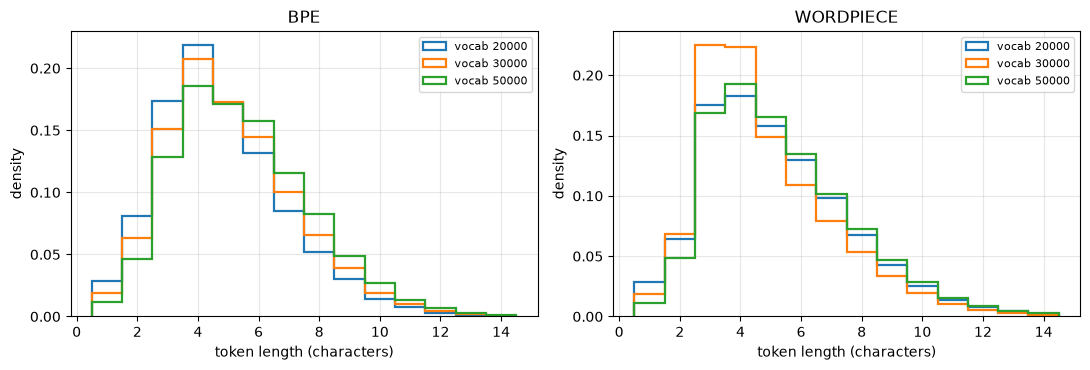

In [30]:
# token-length distributions: how granular is each vocabulary?
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, algo in zip(axes, ("bpe", "wordpiece")):
    for v in CONFIG["vocab_sizes"]:
        tok = TOKENIZERS[(algo, big, v)]
        lens = []
        for t in tok.vocab:
            if t == UNK:
                continue
            core = t[len(CONT):] if t.startswith(CONT) else (
                t[:-len(EOW)] if t.endswith(EOW) else t)
            lens.append(len(core))
        ax.hist(lens, bins=np.arange(0.5, 15.5), density=True, histtype="step", lw=1.6,
                label="vocab %d" % v)
    ax.set_title(algo.upper()); ax.set_xlabel("token length (characters)")
    ax.set_ylabel("density"); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [31]:
# how much do the two algorithms actually agree on their vocabulary?
def core_set(tok, is_wp):
    out = set()
    for t in tok.vocab:
        if t == UNK:
            continue
        out.add(t[len(CONT):] if is_wp else (t[:-len(EOW)] if t.endswith(EOW) else t))
    return out


for v in CONFIG["vocab_sizes"]:
    a = core_set(TOKENIZERS[("bpe", big, v)], False)
    b = core_set(TOKENIZERS[("wordpiece", big, v)], True)
    print("vocab %6d -> BPE %6d, WordPiece %6d, shared %6d  (%.1f%% of BPE)" % (
        v, len(a), len(b), len(a & b), 100.0 * len(a & b) / len(a)))

vocab  20000 -> BPE  17758, WordPiece  11339, shared    291  (1.6% of BPE)
vocab  30000 -> BPE  26906, WordPiece  14799, shared    975  (3.6% of BPE)
vocab  50000 -> BPE  45380, WordPiece  28630, shared   2865  (6.3% of BPE)


In [32]:
# and how stable is a vocabulary as the training data grows?
for algo in ("bpe", "wordpiece"):
    is_wp = algo == "wordpiece"
    ref = core_set(TOKENIZERS[(algo, big, MID_VOCAB)], is_wp)
    print(algo.upper())
    for n_sents in CONFIG["train_sizes"]:
        cur = core_set(TOKENIZERS[(algo, n_sents, MID_VOCAB)], is_wp)
        print("  n=%-9d overlap with the 1M vocabulary: %6d / %6d  (%.1f%%)" % (
            n_sents, len(cur & ref), len(ref), 100.0 * len(cur & ref) / len(ref)))
    print()

BPE
  n=100000    overlap with the 1M vocabulary:  23429 /  26906  (87.1%)
  n=300000    overlap with the 1M vocabulary:  25103 /  26906  (93.3%)
  n=500000    overlap with the 1M vocabulary:  25694 /  26906  (95.5%)
  n=1000000   overlap with the 1M vocabulary:  26906 /  26906  (100.0%)

WORDPIECE
  n=100000    overlap with the 1M vocabulary:   2182 /  14799  (14.7%)
  n=300000    overlap with the 1M vocabulary:   5034 /  14799  (34.0%)
  n=500000    overlap with the 1M vocabulary:   7756 /  14799  (52.4%)
  n=1000000   overlap with the 1M vocabulary:  14799 /  14799  (100.0%)

